[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lshofsl/Thesis/blob/main/NCA_w_RAmod.ipynb)

In [1]:
import os
import sys

!rm -rf Thesis
!git clone https://github.com/lshofsl/Thesis

repo_path = os.path.abspath("Thesis")
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)

if os.path.exists(repo_path):
    print("Success! Files now found:", os.listdir(repo_path))

Cloning into 'Thesis'...
remote: Enumerating objects: 342, done.
remote: Counting objects: 100% (115/115), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 342 (delta 60), reused 69 (delta 29), pack-reused 227 (from 1)
Receiving objects: 100% (342/342), 3.44 MiB | 20.36 MiB/s, done.
Resolving deltas: 100% (165/165), done.
Success! Files now found: ['NCA_with_only_modulation.ipynb', 'NCA_mod.ipynb', 'README.md', 'GeneNCA_RA.ipynb', '.git', 'NCA_baseline.ipynb', 'Images', 'requirements.txt', 'EngramNCA.ipynb', 'NCA_w_RAmod.ipynb', 'Thesis_progress.pdf', 'NCA']


In [2]:
#@title Imports { vertical-output: true}
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import os
import torch

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from NCA.NCA_gene import *
import NCA.utils as utils
from IPython.display import Image, HTML, clear_output
import torch.nn.functional as F
import logging
from IPython.display import display, HTML, Video
from PIL import Image
import cv2
from base64 import b64encode
logger = logging.getLogger()
old_level = logger.level
logger.setLevel(100)

Using device: cuda


In [3]:
#@title Setup { vertical-output: true}
HEIGHT = 60 #@param {type:"integer"}
WIDTH = 60 #@param {type:"integer"}
CHANNELS = 22 # @param {type:"integer"}<--- NCA feature channels
BATCH_SIZE = 12 #@param {type:"integer"}
PADDING = 5 #@param {type:"integer"}
GENE_COUNT = 3 #@param {type:"integer"} <-- Number of gene channels to use for "private" information
RECURRENT_CHANNELS = 3 #@param {type:"integer"} <-- Number of channels for RA computation, these channels are not updated by the NCA and are only used for recurrent processing
MODULATORY_OUTPUT = 3 #@param {type:"integer"} <-- Number of channels for modulatory output, these channels are not updated  and only show the output of the NCA
POOL_SIZE = 2666 #@param {type:"integer"}<--- NCA training pool size, lower values train faster but are less stable
TRAINING_ITERS = 8000  #@param {type:"integer"}<-- Number of trainign iterations
HIDDEN_SIZE = 64 #@param {type:"integer"}<--- NCA hidden size
PRIMITIVES_SHAPES = ["Images/square.png", "Images/circle.png", "Images/triangle.png"]
PRIMITIVES_BODY_PARTS = ["Images/Torso.png", "Images/Head.png", "Images/Tail.png"] # "Images/leg1.png", "Images/leg2.png", "Images/leg3.png", 'Images/leg4.png']
PRIMITIVES_LINES = ["Images/horizontal.png", "Images/Verical.png"]
style = """
<style>
.output_wrapper, .output {
    display: flex;
    flex-direction: row-reverse; /* Align content to the right */
}
</style>
"""

In [4]:
#@title Load Primitives { vertical-output: true}

LIZARD = "Images/lizard.png"
path = LIZARD
image, image_to_display = utils.get_image(os.path.join(repo_path, path), HEIGHT, WIDTH, padding=PADDING)

HEIGHT = HEIGHT + 2*PADDING
WIDTH = WIDTH + 2*PADDING

In [5]:
class SamplePool:
  def __init__(self, *, _parent=None, _parent_idx=None, **slots):
    self._parent = _parent
    self._parent_idx = _parent_idx
    self._slot_names = slots.keys()
    self._size = None
    for k, v in slots.items():
      if self._size is None:
        self._size = len(v)
      assert self._size == len(v)
      setattr(self, k, np.asarray(v))

  def sample(self, n):
    idx = np.random.choice(self._size, n, False)
    batch = {k: getattr(self, k)[idx] for k in self._slot_names}
    batch = SamplePool(**batch, _parent=self, _parent_idx=idx)
    return batch

  def commit(self):
    for k in self._slot_names:
      getattr(self._parent, k)[self._parent_idx] = getattr(self, k)

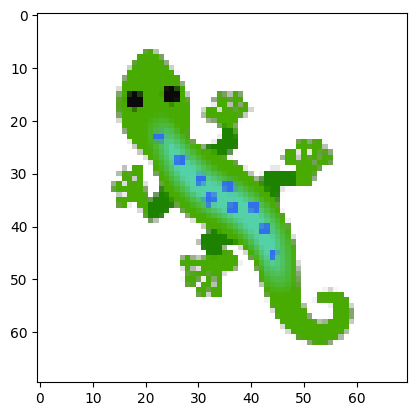

In [6]:
seed = np.zeros([CHANNELS, HEIGHT, WIDTH], np.float32)
seed[3:, HEIGHT // 2, WIDTH // 2] = 1.0

pool = SamplePool(x=np.repeat(seed[None, ...], POOL_SIZE, axis=0))


plt.imshow(image_to_display)
plt.show()

In [7]:
#@title Get Batch Image Partitions { vertical-output: true}
batch = pool.sample(BATCH_SIZE)

In [8]:
#@title Load Filters for Loss Function { vertical-output: true}
sobel_x = torch.tensor([[-1.0, 0.0, 1.0], [-2.0, 0.0, 2.0], [-1.0, 0.0, 1.0]], dtype=torch.float32, device=DEVICE)
lap = torch.tensor([[1.0, 2.0, 1.0], [2.0, -12, 2.0], [1.0, 2.0, 1.0]], dtype=torch.float32, device=DEVICE)
filters = torch.stack([sobel_x, sobel_x.T, lap])
folder = "Gene"

In [9]:
#@title Create Path for Saving Models { vertical-output: true}
path = "Trained_models/" + folder
if not os.path.exists(path):
    os.makedirs(path)
    print(f"Path: {path} created")
else:
    print(f"Path: {path} already exists, all OK!")

Path: Trained_models/Gene created


In [10]:
#@title Initialise NCA { vertical-output: true}
base = image.tile(BATCH_SIZE, 1, 1, 1).to(DEVICE)
loss_log = []
nca = NCA_RAMod(CHANNELS,HIDDEN_SIZE)
nca = nca.to(DEVICE)
optim = torch.optim.AdamW(nca.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optim, step_size=2000, gamma=0.3)
name = folder + "/" +type(nca).__name__

Gene/NCA_RAMod


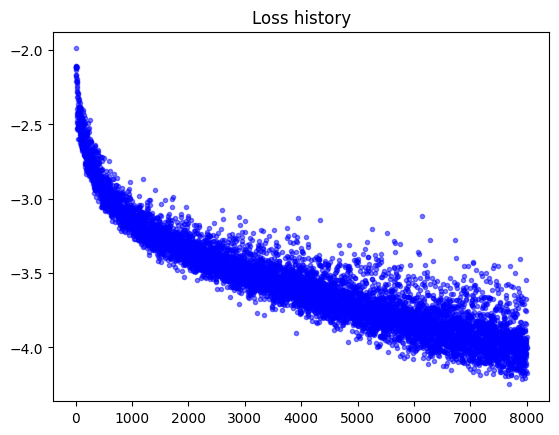

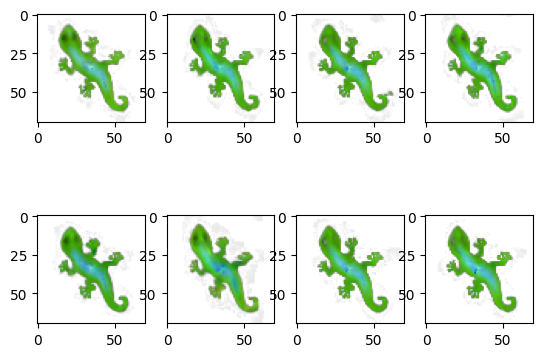

In [11]:
#@title Training { vertical-output: true}

lambda_p = 0.001
lambda_m = 0.01

alpha_log =  []
beta_log   = []
omega_log  = []
K_log      = []
kappa_log  = []
log_iters  = []
a          = []
b          = []
d          = []
first_hiddens = []

for i in range(TRAINING_ITERS + 1):
    with torch.no_grad():
        batch = pool.sample(BATCH_SIZE)
        x = torch.from_numpy(batch.x).to(DEVICE)

    total_amp_loss = torch.zeros(BATCH_SIZE, device=x.device)
    total_smooth_loss = torch.zeros(BATCH_SIZE, device=x.device)

    current_x = x
    itters = random.randrange(32, 92)
    for t in range(itters):
        m_prev = current_x[:, 19:22].clone()

        out, amplitud, phase = nca(current_x, step=t, k=4)
        current_x = out

        live_mask = (current_x[:, 3:4] > 0.1).float()

        amp_num = (amplitud.pow(2) * live_mask).sum(dim=[1, 2, 3])
        amp_den = live_mask.sum(dim=[1, 2, 3]) + 1e-6
        total_amp_loss += amp_num / amp_den

        total_smooth_loss += (current_x[:, 19:22] - m_prev).pow(2).mean(dim=[1, 2, 3])


    x_rgb = current_x[:, :4, :, :]
    per_sample_img_loss = (base - x_rgb).pow(2).mean(dim=[1, 2, 3]) + \
        0.1 * (perchannel_conv(base, filters) - perchannel_conv(x_rgb, filters)).pow(2).mean(dim=[1, 2, 3])

    per_sample_loss = per_sample_img_loss + (lambda_p * total_amp_loss / itters) + (lambda_m * total_smooth_loss / itters)
    loss = per_sample_loss.mean()

    optim.zero_grad()
    loss.backward()


    # Rescale of all the combinations of parameters to not exceed the 1.0 range
    # It perserves the ratio between parameters even after the scaling, is smoother
    torch.nn.utils.clip_grad_norm_(nca.parameters(), max_norm=1.0)

    optim.step()

    loss_log.append(loss.log().item())

    with torch.no_grad():
      x_np = current_x.detach().cpu().numpy()

      # Find worst sample(s) in original order
      per_sample_np = per_sample_loss.detach().cpu().numpy()
      worst_idx = per_sample_np.argmax()  # single worst
      x_np[worst_idx] = seed  # reseed at original position
      batch.x[:] = x_np
      batch.commit()  # The pool is updated depending on its positions

    scheduler.step()

    if i % 100 == 0:
        print(f"Training itter {i}, loss = {loss.item()}")
        plt.clf()
        clear_output()
        plt.figure(1,figsize=(10, 4))
        plt.title('Loss history')
        print(name)
        plt.plot(loss_log, '.', alpha=0.5, color = "b")
        utils.show_batch(x[2:10])
        plt.show(block=False)
        plt.pause(0.01)

        alpha_log.append(nca.alpha.item())
        beta_log.append(nca.beta.item())
        omega_log.append(nca.omega.item())
        K_log.append(nca.K.item())
        kappa_log.append(nca.kappa.item())
        log_iters.append(i)
        a.append(current_x[:,16:17].detach().cpu().numpy())
        b.append(current_x[:,17:18].detach().cpu().numpy())
        d.append(current_x[:,18:19].detach().cpu().numpy())
        first_hiddens.append(current_x[:, 4:8].detach().cpu().numpy())


    if i % 100 == 0:
        torch.save(nca.state_dict(), "Trained_models/" + name + ".pth")

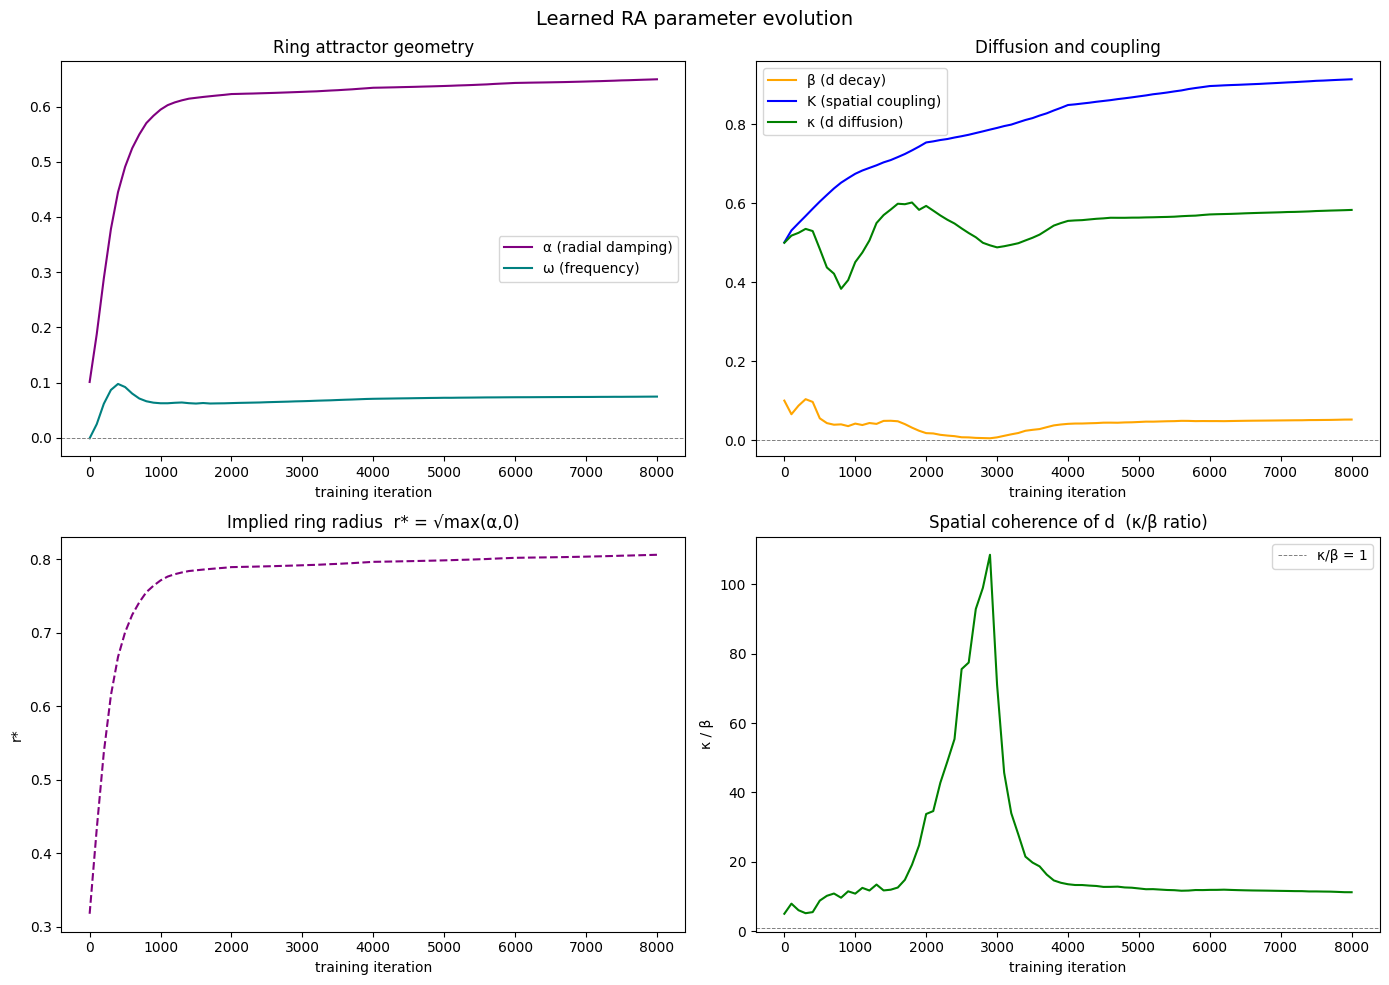

=== Converged parameter values ===
  α = 0.6494  ✓ stable ring
  ω = 0.0745  ✓ rotating
  β = 0.0520
  K = 0.9144
  κ = 0.5833
  r* = 0.8059
  κ/β = 11.2126


In [12]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Learned RA parameter evolution', fontsize=14)

# --- α and ω: ring geometry ---
ax = axes[0, 0]
ax.plot(log_iters, alpha_log, label='α (radial damping)', color='purple')
ax.plot(log_iters, omega_log, label='ω (frequency)',      color='teal')
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_title('Ring attractor geometry')
ax.set_xlabel('training iteration')
ax.legend()

# --- β, K, κ: diffusion and coupling ---
ax = axes[0, 1]
ax.plot(log_iters, beta_log,  label='β (d decay)',          color='orange')
ax.plot(log_iters, K_log,     label='K (spatial coupling)', color='blue')
ax.plot(log_iters, kappa_log, label='κ (d diffusion)',      color='green')
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_title('Diffusion and coupling')
ax.set_xlabel('training iteration')
ax.legend()

# --- r* = sqrt(max(α,0)): learned ring radius ---
ax = axes[1, 0]
r_star = [np.sqrt(max(a, 0)) for a in alpha_log]
ax.plot(log_iters, r_star, color='purple', linestyle='--')
ax.set_title('Implied ring radius  r* = √max(α,0)')
ax.set_xlabel('training iteration')
ax.set_ylabel('r*')

# --- κ/β ratio: spatial coherence length of d ---
ax = axes[1, 1]
coherence = [k / (b + 1e-8) for k, b in zip(kappa_log, beta_log)]
ax.plot(log_iters, coherence, color='green')
ax.axhline(1, color='gray', linewidth=0.7, linestyle='--', label='κ/β = 1')
ax.set_title('Spatial coherence of d  (κ/β ratio)')
ax.set_xlabel('training iteration')
ax.set_ylabel('κ / β')
ax.legend()

plt.tight_layout()
plt.savefig('ra_parameter_evolution.png', dpi=150)
plt.show()

# Numerical summary at convergence
print("=== Converged parameter values ===")
print(f"  α = {alpha_log[-1]:.4f}  {'✓ stable ring' if alpha_log[-1] > 0 else '✗ unstable — consider softplus constraint'}")
print(f"  ω = {omega_log[-1]:.4f}  {'✓ rotating' if abs(omega_log[-1]) > 1e-3 else '✗ frozen phase'}")
print(f"  β = {beta_log[-1]:.4f}")
print(f"  K = {K_log[-1]:.4f}")
print(f"  κ = {kappa_log[-1]:.4f}")
print(f"  r* = {r_star[-1]:.4f}")
print(f"  κ/β = {coherence[-1]:.4f}")


In [13]:
a = np.array(a)
b = np.array(b)
d = np.array(d)
first_hiddens = np.array(first_hiddens)

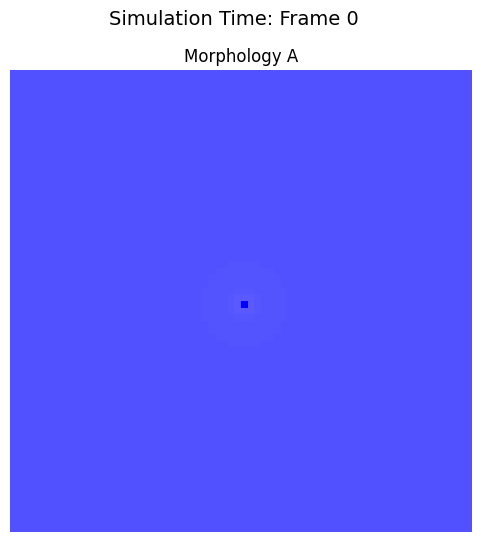

In [16]:
reshaped_data = a.reshape(81, 12, 1, 70, 70)

grid_data = reshaped_data[:, 0, 0, :, :]

fig, ax = plt.subplots(figsize=(6, 6))
morphology_name = "Morphology A"

im = ax.imshow(grid_data[0], cmap='bwr', vmin=grid_data.min(), vmax=grid_data.max())
ax.set_title(morphology_name)
ax.axis('off')


def update(t_idx):
    actual_frame = log_iters[t_idx]
    fig.suptitle(f"Simulation Time: Frame {actual_frame}", fontsize=14)

    im.set_array(grid_data[t_idx])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(log_iters), interval=100, blit=False)

ani.save('morphology_a_single.gif', writer='pillow', fps=10)

In [17]:
del nca
del optim
torch.cuda.empty_cache()

In [44]:
nca = NCA_RAMod(CHANNELS,hidden_n=HIDDEN_SIZE)
nca.load_state_dict(torch.load("Trained_models/Gene/NCA_RAMod.pth"))
nca.to(DEVICE).eval()

NCA_RAMod(
  (w1): Conv2d(80, 64, kernel_size=(1, 1), stride=(1, 1))
  (w2): Conv2d(64, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (slow_input_net): Conv2d(5, 3, kernel_size=(1, 1), stride=(1, 1))
  (mod_output_net): Conv2d(3, 3, kernel_size=(1, 1), stride=(1, 1))
  (film_gamma): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  (film_beta): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
)

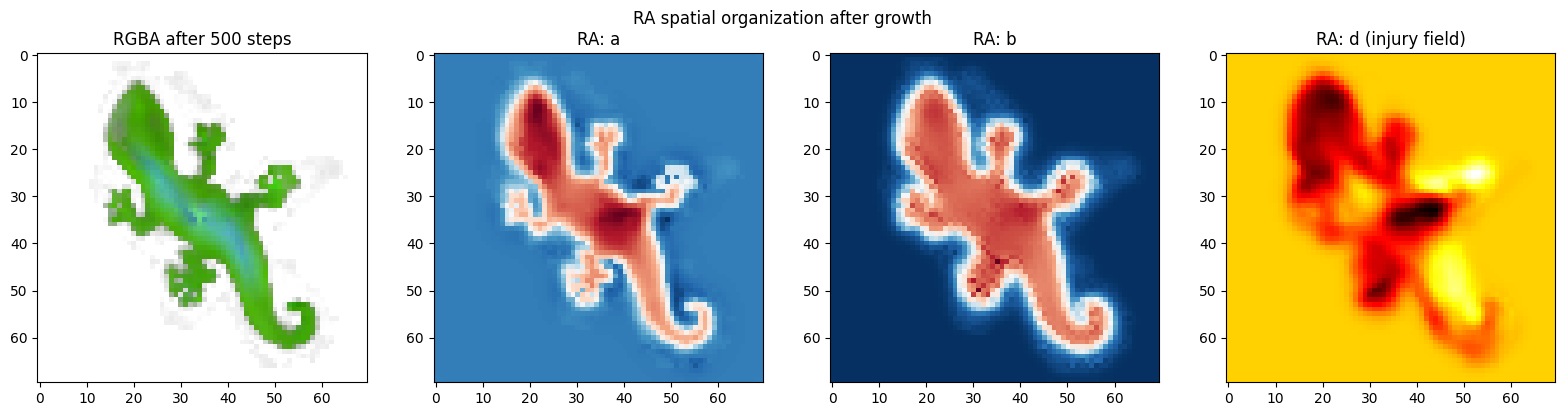

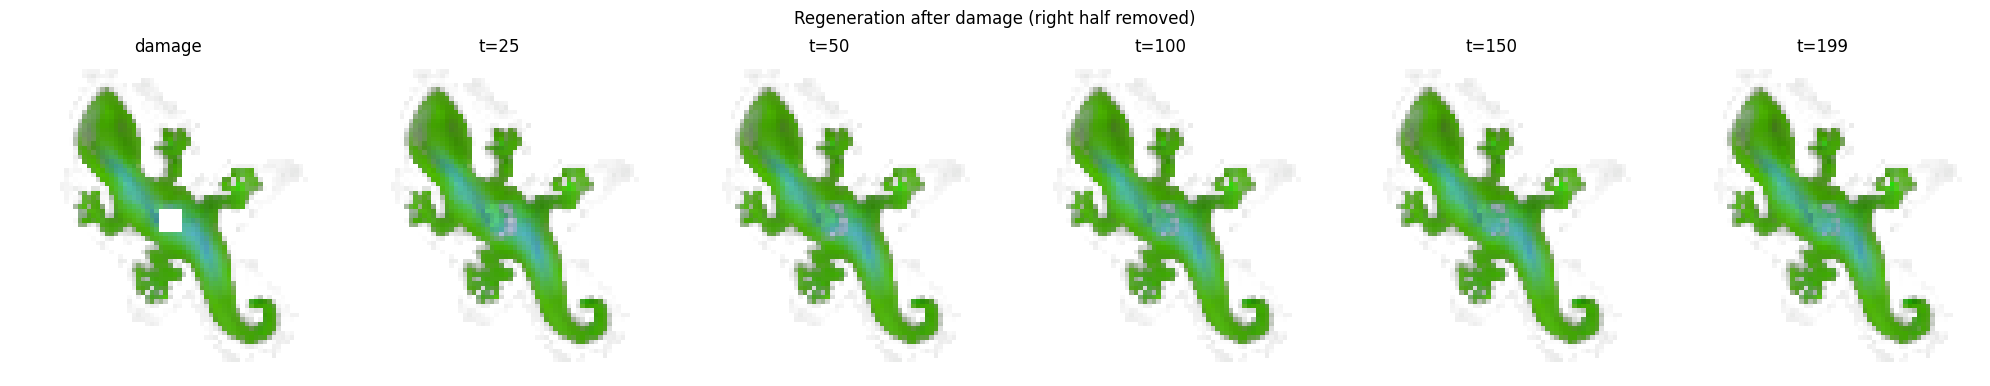

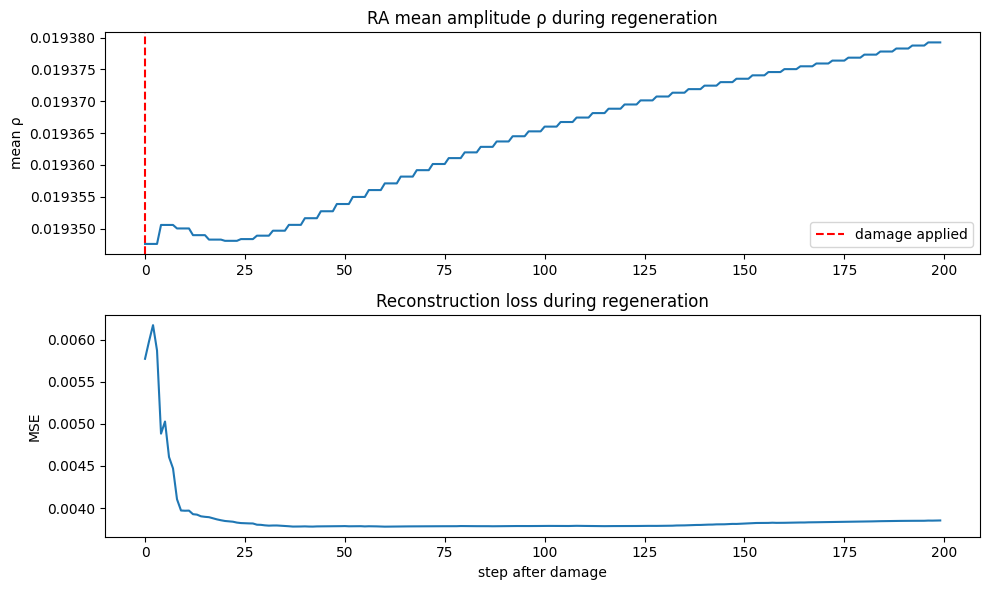

In [27]:
with torch.no_grad():
    # Start from a pool sample — guaranteed good starting state
    x_test = torch.from_numpy(seed[None, ...]).to(DEVICE) if isinstance(seed, np.ndarray) else seed.to(DEVICE)

    # Grow for 100 steps
    for t in range(500):
        x_test, phase, amp = nca(x_test, step=t, k=4)

    # --- Plot 1: What it looks like after growth ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    axes[0].imshow(x_test[0, :4].permute(1,2,0).cpu().clip(0,1))
    axes[0].set_title('RGBA after 500 steps')
    axes[1].imshow(x_test[0, 16].cpu(), cmap='RdBu')
    axes[1].set_title('RA: a')
    axes[2].imshow(x_test[0, 17].cpu(), cmap='RdBu')
    axes[2].set_title('RA: b')
    axes[3].imshow(x_test[0, 18].cpu(), cmap='hot')
    axes[3].set_title('RA: d (injury field)')
    plt.suptitle('RA spatial organization after growth')
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Damage experiment ---
    x_damaged = x_test.clone()
    _, _, H, W = x_damaged.shape

# 2. Define the circle's center and radius
# (Defaulting to the exact center of the image, with a radius of 15% of the width)
    center_y, center_x = H // 2, W // 2
    radius = int(0.05 * min(H, W))

# 3. Create a 2D coordinate grid of (y, x) coordinates
    y_indices = torch.arange(H).view(H, 1)
    x_indices = torch.arange(W).view(1, W)

# 4. Calculate the squared Euclidean distance from the center for every pixel
    distance_squared = (y_indices - center_y) ** 2 + (x_indices - center_x) ** 2

# 5. Create a boolean mask where True means "inside the circle"
# (Using distance^2 < radius^2 to avoid slow square root operations)
    circular_mask = distance_squared < (radius ** 2)

# 6. Apply the mask across all batches and channels
# (PyTorch automatically broadcasts the [H, W] mask to [B, C, H, W])
    x_damaged[:, :, circular_mask] = 0

    amps, losses = [], []
    frames_damaged = [x_damaged[0, :4].permute(1,2,0).cpu().clip(0,1)]

    for t in range(200):
        x_damaged, amp, phase = nca(x_damaged, step=t, k=4)
        amps.append(amp.mean().item())
        losses.append((base[0:1] - x_damaged[:, :4]).pow(2).mean().item())
        if t in [25, 50, 100, 150, 199]:
            frames_damaged.append(
                x_damaged[0, :4].permute(1,2,0).cpu().clip(0,1)
            )

    # Show regeneration frames
    fig, axes = plt.subplots(1, len(frames_damaged), figsize=(20, 4))
    titles = ['damage'] + [f't={t}' for t in [25, 50, 100, 150, 199]]
    for ax, frame, title in zip(axes, frames_damaged, titles):
        ax.imshow(frame)
        ax.set_title(title)
        ax.axis('off')
    plt.suptitle('Regeneration after damage (right half removed)')
    plt.tight_layout()
    plt.show()

    # --- Plot 3: RA amplitude and loss over regeneration ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6))
    ax1.plot(amps)
    ax1.axvline(x=0, color='r', linestyle='--', label='damage applied')
    ax1.set_title('RA mean amplitude ρ during regeneration')
    ax1.set_ylabel('mean ρ')
    ax1.legend()
    ax2.plot(losses)
    ax2.set_title('Reconstruction loss during regeneration')
    ax2.set_ylabel('MSE')
    ax2.set_xlabel('step after damage')
    plt.tight_layout()
    plt.show()


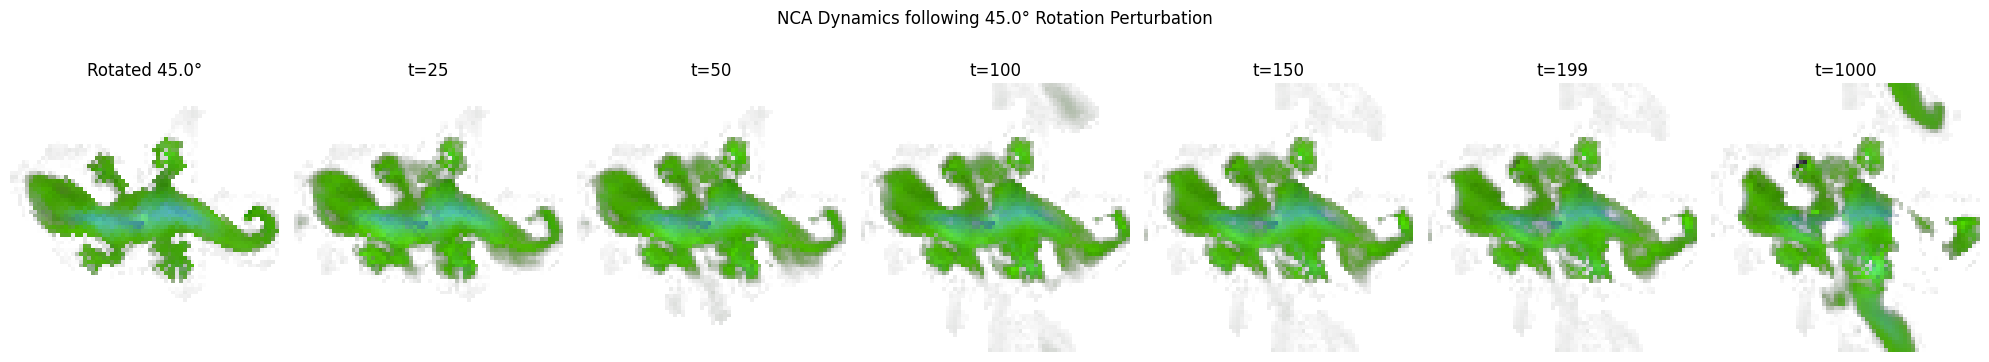

In [45]:

import torchvision.transforms.v2.functional as TF

ROTATION_ANGLE = 45.0  # Try 45, 90, or 180 degrees

# 1. Rotate x_test
x_rotated = TF.rotate(x_test.clone(), angle=ROTATION_ANGLE)

amps_rot, losses_rot = [], []

# Use .detach() before moving to CPU/NumPy
frames_rotated = [x_rotated[0, :4].permute(1, 2, 0).detach().cpu().clip(0, 1)]

# 2. Run NCA rollouts on the rotated state
with torch.no_grad():  # Prevents building unused grad graphs
    for t in range(1001):
        x_rotated, amp, phase = nca(x_rotated, step=t, k=4)
        amps_rot.append(amp.mean().item())
        losses_rot.append((base[0:1] - x_rotated[:, :4]).pow(2).mean().item())

        if t in [25, 50, 100, 150, 199, 1000]:
            frames_rotated.append(
                x_rotated[0, :4].permute(1, 2, 0).detach().cpu().clip(0, 1)
            )

    # 3. Show rotation recovery frames
fig, axes = plt.subplots(1, len(frames_rotated), figsize=(20, 4))
titles = [f'Rotated {ROTATION_ANGLE}°'] + [f't={t}' for t in [25, 50, 100, 150, 199, 1000]]
for ax, frame, title in zip(axes, frames_rotated, titles):
    ax.imshow(frame)
    ax.set_title(title)
    ax.axis('off')
plt.suptitle(f'NCA Dynamics following {ROTATION_ANGLE}° Rotation Perturbation')
plt.tight_layout()
plt.show()

In [43]:
del nca
torch.cuda.empty_cache()